In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Load Dataset

In [67]:
df=pd.read_csv('yield_df.csv')

In [68]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [69]:
df.shape

(28242, 8)

In [70]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='str')

Dataset Information

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [72]:
df.dtypes

Unnamed: 0                         int64
Area                                 str
Item                                 str
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Statistical Summary Check

In [73]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


Missing Values

In [74]:
df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [75]:
df = df.dropna()

In [76]:
df

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.00,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.00,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.00,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.00,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.00,16.37
...,...,...,...,...,...,...,...,...
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76


check Duplicates

In [77]:
df.duplicated().sum()

np.int64(0)

Outlier Detection

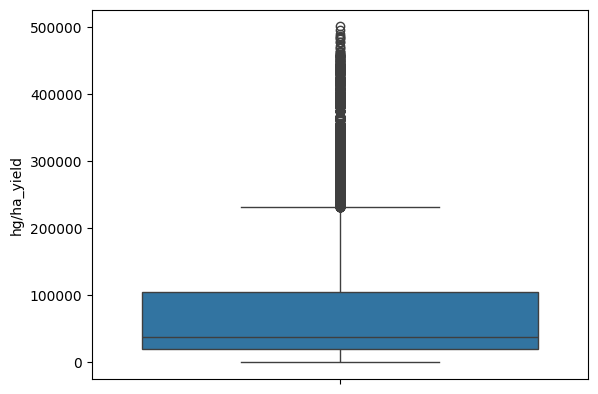

In [78]:
sns.boxplot(df['hg/ha_yield'])
plt.show()

Normalization

In [79]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

cols = ['average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp','hg/ha_yield']

df[cols] = scaler.fit_transform(df[cols])

In [80]:
df[cols]

,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,0.449671,0.000329,0.513458,0.072927
1,0.449671,0.000329,0.513458,0.132872
2,0.449671,0.000329,0.513458,0.046439
3,0.449671,0.000329,0.513458,0.024832
4,0.449671,0.000329,0.513458,0.013862
...,...,...,...,...
28237,0.190028,0.006934,0.628961,0.044940
28238,0.190028,0.006934,0.628961,0.006016
28239,0.190028,0.006934,0.628961,0.026113
28240,0.190028,0.006934,0.628961,0.044224


Check Final Dataset Shape

In [81]:
df.shape

(28242, 8)

In [82]:
df.head(3)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,0.072927,0.449671,0.000329,0.513458
1,1,Albania,Potatoes,1990,0.132872,0.449671,0.000329,0.513458
2,2,Albania,"Rice, paddy",1990,0.046439,0.449671,0.000329,0.513458


Boxplot After Cleaning

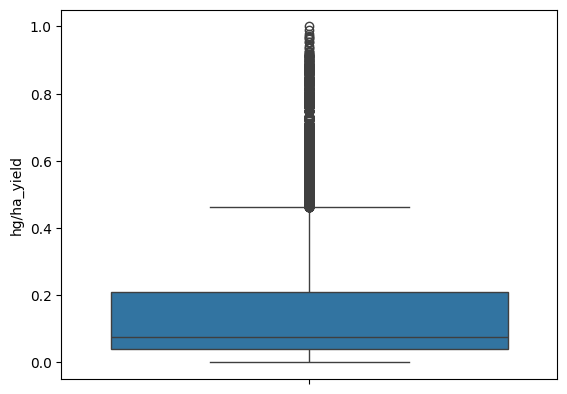

In [83]:
sns.boxplot(df['hg/ha_yield'])
plt.show()

Histogram

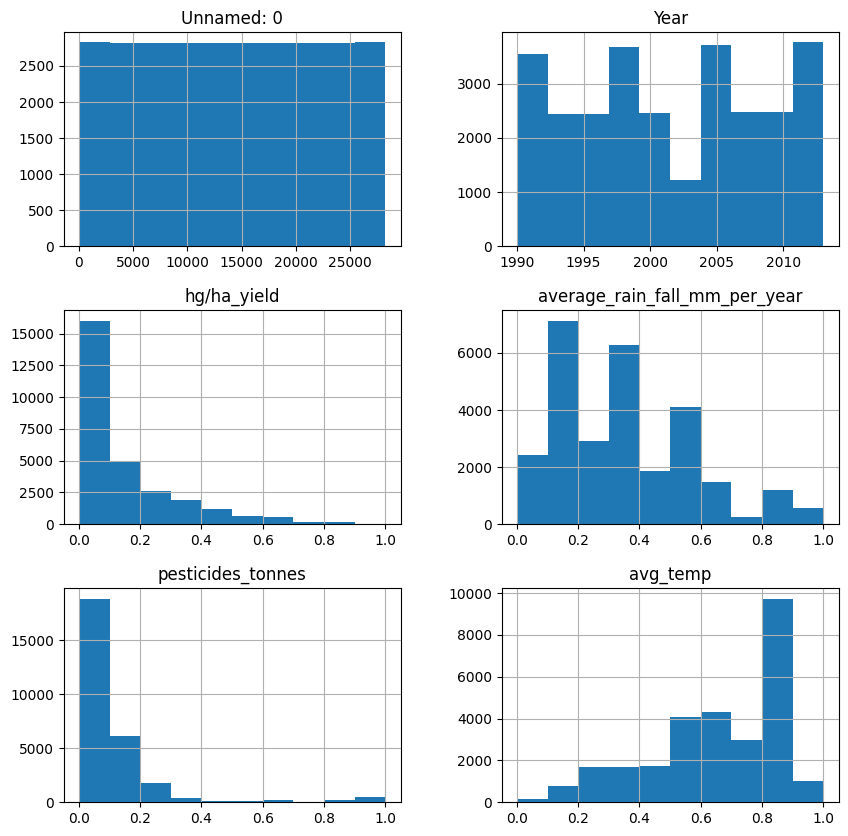

In [84]:
df.hist(figsize=(10,10))
plt.show()

Save Cleaned Dataset

In [85]:
df.to_csv("cleaned_crop_dataset.csv", index=False)